In [1]:
import numpy as np

from pint.models import get_model_and_toas
from pint.logging import setup as setup_log

from enterprise_wideband.pulsar import WidebandPulsar
from enterprise_wideband.signals import WidebandTimingModel, WidebandMeasurementNoise
from enterprise_wideband.blocks import achromatic_red_noise_powerlaw_block, dm_noise_powerlaw_block
from enterprise.signals.signal_base import PTA

from PTMCMCSampler.PTMCMCSampler import PTSampler
import corner

/home/abhimanyu/miniconda3/envs/wideband-dev/lib/python3.12/site-packages/enterprise/signals/utils.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import Requirement, resource_filename
libstempo not installed. PINT or libstempo are required to use par and tim files.


Optional mpi4py package is not installed.  MPI support is not available.


In [2]:
setup_log(level="WARNING")

1

In [ ]:
# This dataset is from Susobhanan & van Haasteren 2025 (https://arxiv.org/abs/2505.05274).
parfile = "sim.par"
timfile = "sim.tim"
m, t = get_model_and_toas(parfile, timfile, planets=True)
psr = WidebandPulsar(t, m)

WARNING  (pint.logging                  ): /home/abhimanyu/miniconda3/envs/wideband-dev/lib/python3.12/site-packages/pint/observatory/clock_file.py:183 UserWarning: Data points out of range in clock file 'time_gbt.dat'


In [37]:
tm = WidebandTimingModel()
wn = WidebandMeasurementNoise()
arn = achromatic_red_noise_powerlaw_block(components=120)
dmn = dm_noise_powerlaw_block(components=120)

In [38]:
model = tm + wn + arn + dmn

pta = PTA([model(psr)])

In [39]:
print(pta.param_names)

['J0500+1500_sim_powerlaw_achromatic_red_noise_gamma', 'J0500+1500_sim_powerlaw_achromatic_red_noise_log10_A', 'J0500+1500_sim_powerlaw_dm_noise_gamma', 'J0500+1500_sim_powerlaw_dm_noise_log10_A', 'J0500+1500_sim_wideband_white_noise_dmefac', 'J0500+1500_sim_wideband_white_noise_efac']


In [40]:
x0 = np.array([p.sample() for p in pta.params])

In [41]:
# dimension of parameter space
ndim = len(x0)

# initial jump covariance matrix
cov = np.diag(np.ones(ndim) * 0.01**2)

# intialize sampler
sampler = PTSampler(ndim, pta.get_lnlikelihood, pta.get_lnprior, cov, outDir="chains/")

In [42]:
N = 100000
sampler.sample(x0, N, SCAMweight=30, AMweight=15, DEweight=50)

Finished 0.00 percent in 0.000752 s Acceptance rate = 0

WARNING  (pint.logging                  ): /home/abhimanyu/miniconda3/envs/wideband-dev/lib/python3.12/site-packages/enterprise/signals/parameter.py:70 RuntimeWarning: divide by zero encountered in log


Finished 10.00 percent in 87.713711 s Acceptance rate = 0.25356Adding DE jump with weight 50
Finished 100.00 percent in 764.583779 s Acceptance rate = 0.34338
Run Complete


In [43]:
chain = np.loadtxt("chains/chain_1.txt")
burn = int(0.25 * chain.shape[0])

In [44]:
labels = [
    'gamma_arn', 'log10_A_arn', 'gamma_dmn', 'log10_A_dmn', 'dmefac', 'efac'
]

true_values = [4, -13, 3, -13, 1, 1]

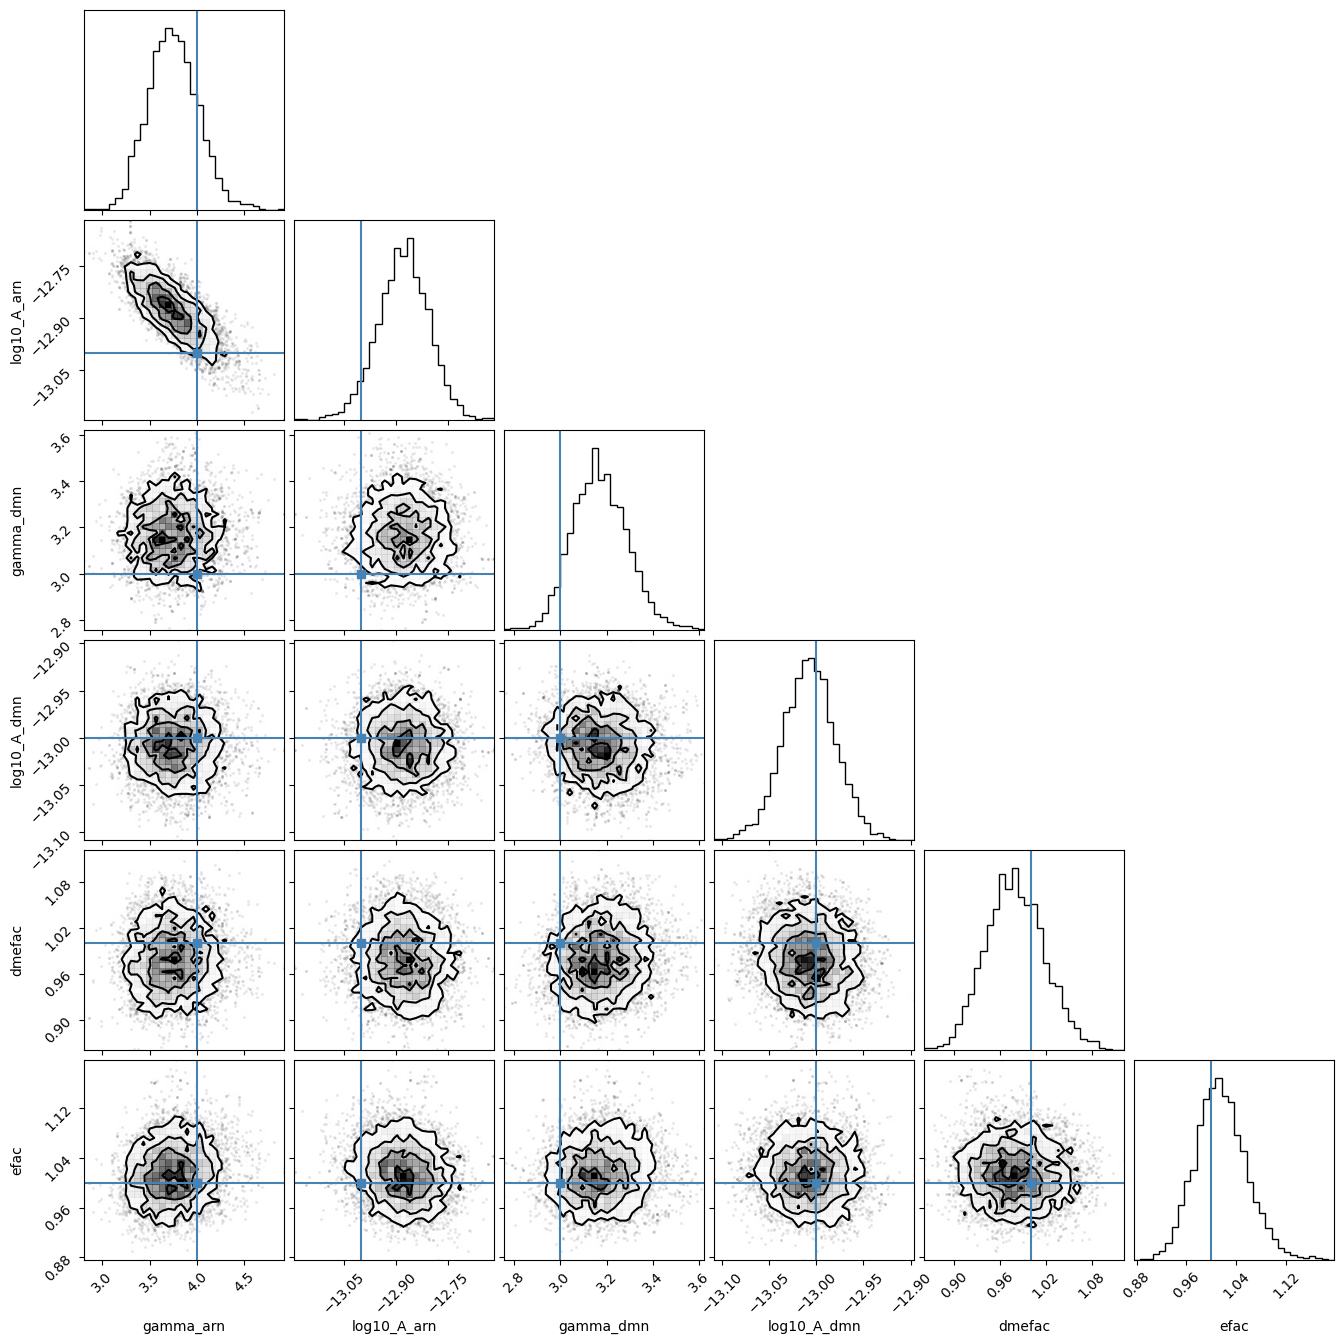

In [45]:
corner.corner(
    chain[burn:, :-4],
    bins=32,
    truths=true_values,
    labels=labels,
);